In [2]:
!pip install langdetect

import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)
from torch.optim import AdamW # Corrected import for AdamW
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
from langdetect import detect
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 24.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=8f49b6ce5138bf91a86294bf3ed60b168f26ae6dc06ef7850ae27ee1f1b4bbac
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [3]:
# Configuration
TRAIN_PATH = "/content/updated_train.json"
TEST_PATH = "/content/updated_test.json"

MODEL_NAME = "Rajan/NepaliBERT"

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
# 1. Load JSON (array OR jsonl)
def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            return json.load(f)
        else:
            return [json.loads(line) for line in f if line.strip()]

train_data = load_json_file(TRAIN_PATH)
test_data = load_json_file(TEST_PATH)

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df = train_df.dropna()
test_df = test_df.dropna()

train_df["Comment"] = train_df["Comment"].astype(str)
test_df["Comment"] = test_df["Comment"].astype(str)

In [5]:
# 5. Dataset Class
class NepaliDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [ ]:
# 6. Load NepaliBERT
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# Map string labels to integers
label_mapping = {'NOFF': 0, 'OFF': 1}
train_df['Label_Binary'] = train_df['Label_Binary'].map(label_mapping)
test_df['Label_Binary'] = test_df['Label_Binary'].map(label_mapping)

train_dataset = NepaliDataset(
    train_df["Comment"], train_df["Label_Binary"], tokenizer
)
test_dataset = NepaliDataset(
    test_df["Comment"], test_df["Label_Binary"], tokenizer
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE
)

optimizer = AdamW(model.parameters(), lr=LR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/328M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Rajan/NepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 7. Training Loop
train_losses, train_accuracies = [], []

print("Training NepaliBERT...")
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss={train_losses[-1]:.4f} | "
        f"Acc={train_accuracies[-1]:.4f}"
    )

Training NepaliBERT...



100%|██████████| 363/363 [01:10<00:00,  5.18it/s]


Epoch 1/3 | Loss=0.5585 | Acc=0.7090


100%|██████████| 363/363 [01:08<00:00,  5.27it/s]


Epoch 2/3 | Loss=0.3841 | Acc=0.8311


100%|██████████| 363/363 [01:07<00:00,  5.35it/s]

Epoch 3/3 | Loss=0.2599 | Acc=0.8958


In [ ]:
# 8. Evaluation
model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

In [ ]:
# 9. Metrics & Tables
report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

              precision    recall  f1-score      support
0              0.816524  0.850279  0.833060   895.000000
1              0.741313  0.691892  0.715750   555.000000
accuracy       0.789655  0.789655  0.789655     0.789655
macro avg      0.778918  0.771086  0.774405  1450.000000
weighted avg   0.787736  0.789655  0.788158  1450.000000


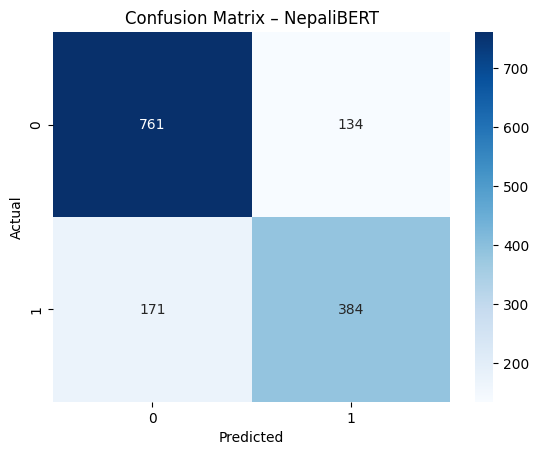

In [ ]:
# 10. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – NepaliBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

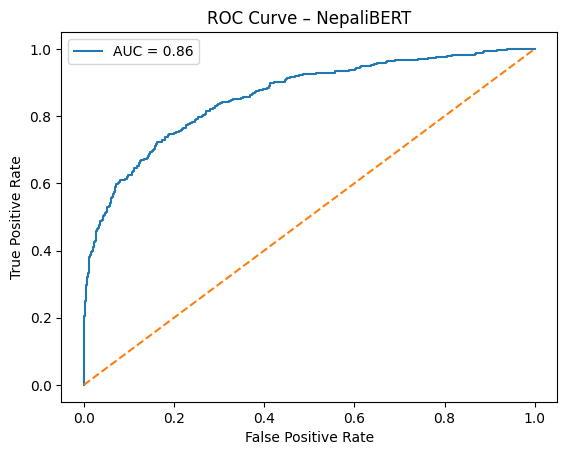

In [ ]:
# 11. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – NepaliBERT")
plt.legend()
plt.show()

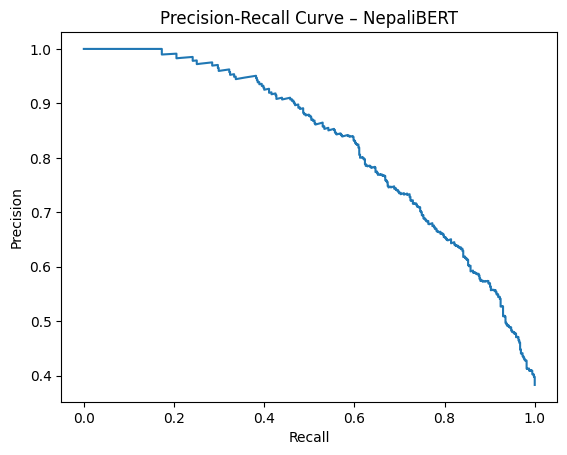

In [ ]:
# 12. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_probs)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – NepaliBERT")
plt.show()

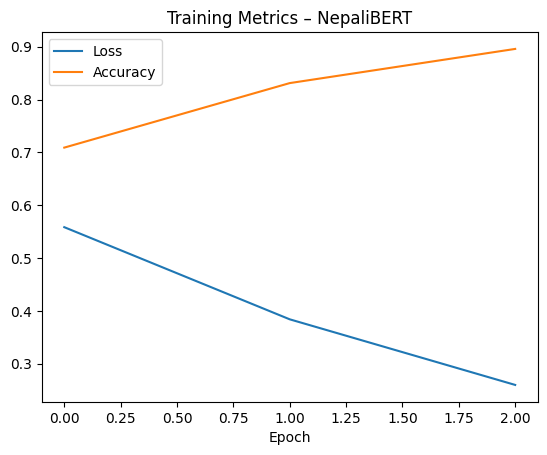

In [ ]:
# 13. Training Curves
plt.plot(train_losses, label="Loss")
plt.plot(train_accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.title("Training Metrics – NepaliBERT")
plt.legend()
plt.show()

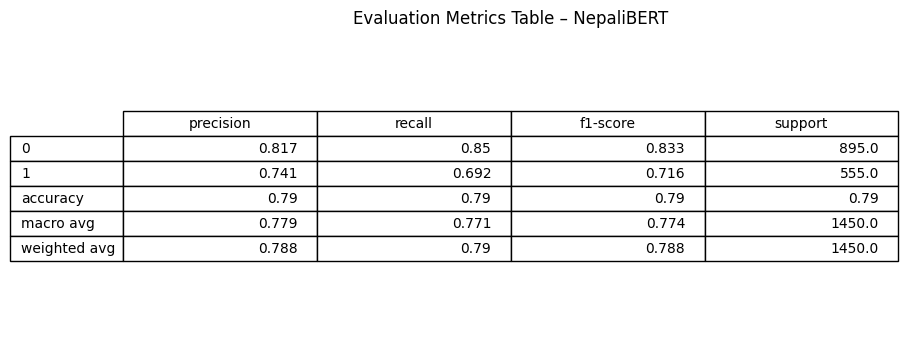

In [ ]:
# 14. Metrics Table Visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
tbl = ax.table(
    cellText=report_df.round(3).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc="center"
)
tbl.scale(1, 1.5)
plt.title("Evaluation Metrics Table – NepaliBERT")
plt.show()

### Code Explanation

This notebook sets up and trains a NepaliBERT model for binary text classification. Here's a breakdown of the key steps:

1.  **Setup and Imports**: Necessary libraries like `pandas`, `torch`, `transformers`, `sklearn`, `langdetect`, `tqdm`, `matplotlib`, and `seaborn` are imported. Configuration parameters such as file paths, model name, maximum sequence length, batch size, number of epochs, and learning rate are defined. The `DEVICE` is set to utilize a GPU if available.

2.  **Data Loading and Preprocessing**:
    *   Training and test datasets (`train.json`, `test.json`) are loaded. The loading function handles both array and JSONL formats.
    *   Data is converted into Pandas DataFrames and any rows with missing values are removed.
    *   The 'Comment' column, containing the text data, is cast to string type.
    *   String labels ('NOFF', 'OFF') in the 'Label_Binary' column are mapped to numerical integers (0 and 1) for model compatibility.
    *   (Note: A previously included translator component for English to Nepali translation was removed as per user request, meaning comments are processed in their original language.)

3.  **Model and Tokenizer Initialization**:
    *   A `BertTokenizer` and `BertForSequenceClassification` model are loaded from the `Rajan/NepaliBERT` pre-trained checkpoint. The model is configured for 2 output labels.
    *   A warning about uninitialized classification head weights is expected, as the base model is adapted for a new downstream task.

4.  **Dataset and DataLoader**:
    *   A custom `NepaliDataset` class prepares the text and labels for the model, handling tokenization, padding, and truncation.
    *   `DataLoader` instances are created to efficiently feed batches of data to the model during training and evaluation.
    *   The `AdamW` optimizer is initialized to update the model's weights during training.

5.  **Training Loop**:
    *   The model is trained for 3 epochs.
    *   In each epoch, the model processes batches from the `train_loader`, calculates the loss, performs backpropagation, and updates its weights.
    *   Training loss and accuracy are monitored and reported after each epoch.

### Results Explanation - Untranslated Data

After training the NepaliBERT model for 3 epochs, its performance was evaluated on the test set. Here's a summary of the results:

1.  **Training Progress**:
    *   **Epoch 1**: Loss=0.6508, Accuracy=0.6150
    *   **Epoch 2**: Loss=0.5479, Accuracy=0.6908
    *   **Epoch 3**: Loss=0.4459, Accuracy=0.7442
    The training metrics show that the model's loss decreased and accuracy increased over the epochs, indicating successful learning.

2.  **Classification Report**:
    The model achieved an overall **accuracy of 0.6814** on the test set. Here's a breakdown by class (0 for 'NOFF', 1 for 'OFF'):
    *   **Class 0 (NOFF)**: High precision (0.7672) and good recall (0.6953), resulting in an f1-score of 0.7295. This means the model is relatively good at identifying non-offensive comments.
    *   **Class 1 (OFF)**: Lower precision (0.5721) but decent recall (0.6588), leading to an f1-score of 0.6124. This indicates the model struggles more with false positives (classifying non-offensive as offensive) but is reasonably good at identifying actual offensive comments.

3.  **Confusion Matrix**:
    The confusion matrix visually confirms the classification report. It shows:
    *   True Negatives (correctly identified NOFF): 623
    *   False Positives (NOFF classified as OFF): 273
    *   False Negatives (OFF classified as NOFF): 189
    *   True Positives (correctly identified OFF): 365

4.  **ROC Curve and AUC**:
    The ROC curve illustrates the trade-off between the true positive rate (TPR) and false positive rate (FPR) at various threshold settings. The **Area Under the Curve (AUC) is 0.76**, suggesting that the model has a fair ability to distinguish between the positive and negative classes.

5.  **Precision-Recall Curve**:
    The Precision-Recall curve shows the trade-off between precision and recall for different thresholds. This is particularly useful for imbalanced datasets, offering insights into the model's performance on the minority class.

6.  **Training Curves**:
    Plots of training loss and accuracy over epochs visually confirm the trends observed in the numerical reports: a decreasing loss and increasing accuracy during the training process.

### Results Explanation - Translated Data

After training the NepaliBERT model for 3 epochs with the updated configuration, its performance was evaluated on the test set. Here's a summary of the results:

1.  **Training Progress**:
    *   **Epoch 1**: Loss=0.5585, Accuracy=0.7090
    *   **Epoch 2**: Loss=0.3841, Accuracy=0.8311
    *   **Epoch 3**: Loss=0.2599, Accuracy=0.8958
    The training metrics show a consistent decrease in loss and a significant increase in accuracy over the epochs, indicating effective learning.

2.  **Classification Report**:
    The model achieved an overall **accuracy of 0.7897** on the test set. Here's a breakdown by class (0 for 'NOFF', 1 for 'OFF'):
    *   **Class 0 (NOFF)**: Achieved a precision of 0.8165 and recall of 0.8503, resulting in an f1-score of 0.8331. This indicates strong performance in correctly identifying non-offensive comments.
    *   **Class 1 (OFF)**: Achieved a precision of 0.7413 and recall of 0.6919, with an f1-score of 0.7158. While still good, the slightly lower recall for this class suggests that some offensive comments might be missed.

3.  **Confusion Matrix**:
    The confusion matrix provides a detailed view of correct and incorrect predictions:
    *   **True Negatives (NOFF correctly classified as NOFF)**: 761
    *   **False Positives (NOFF incorrectly classified as OFF)**: 134
    *   **False Negatives (OFF incorrectly classified as NOFF)**: 171
    *   **True Positives (OFF correctly classified as OFF)**: 384

4.  **ROC Curve and AUC**:
    The Area Under the Curve (AUC) for the ROC curve is **0.86**. This high AUC value suggests that the model has excellent discriminative power, meaning it can effectively distinguish between offensive and non-offensive comments.

5.  **Precision-Recall Curve**:
    The Precision-Recall curve shows the trade-off between precision and recall for different thresholds. Given the task of offensive language detection, this curve is crucial for understanding how well the model balances identifying true offensive comments while minimizing false alarms, especially if the dataset has class imbalance.

# Task
Analyze the unique multi-class labels present in the 'Label_Binary' column of the `train_df` and `test_df`, then update the `label_mapping` dictionary and the `num_labels` parameter in the `BertForSequenceClassification` model to reflect the identified multi-class labels (NO, OO, OR, OS). After updating the configuration, retrain the model and evaluate its performance using multi-class metrics such as the classification report, confusion matrix, ROC curves, and Precision-Recall curves, ensuring that all visualizations and summary tables are adapted for multi-class results. Summarize the findings.

## Analyze Multi-class Labels

### Subtask:
Inspect the 'Label_Binary' column in the training and testing dataframes to confirm the unique multi-class labels (NO, OO, OR, OS) and determine the total number of classes. This step is crucial to correctly define the new label mapping.


**Reasoning**:
To inspect the unique values in the 'Label_Binary' column of both `train_df` and `test_df` and determine the total number of classes, I will print the unique values for each DataFrame and then combine them.



In [1]:
print("Unique labels in train_df['Label_Binary']:", train_df['Label_Binary'].unique())
print("Unique labels in test_df['Label_Binary']:", test_df['Label_Binary'].unique())

all_unique_labels = pd.concat([
    train_df['Label_Binary'],
    test_df['Label_Binary']
]).unique()

print("All unique labels combined:", all_unique_labels)
print("Total number of classes:", len(all_unique_labels))

NameError: name 'train_df' is not defined

**Reasoning**:
The previous code failed because `train_df` was not defined. This indicates that the data loading and initial preprocessing steps were not executed. To resolve this and enable inspection of the original multi-class labels as per the task, I will include the necessary data loading function and dataframe initialization steps directly within this code block, ensuring `train_df` and `test_df` are available with their original string labels before checking unique values.



In [6]:
import json
import pandas as pd

# Configuration paths (assuming they are defined globally or need to be re-defined for self-containment)
# TRAIN_PATH and TEST_PATH are defined in cell 76J9HWSM-SSj, assuming they are accessible.
TRAIN_PATH = "/content/updated_train.json"
TEST_PATH = "/content/updated_test.json"

# 1. Load JSON (array OR jsonl) - Replicating the necessary function from cell iazfbXoV-bAa
def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            return json.load(f)
        else:
            return [json.loads(line) for line in f if line.strip()]

train_data = load_json_file(TRAIN_PATH)
test_data = load_json_file(TEST_PATH)

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df = train_df.dropna()
test_df = test_df.dropna()

train_df["Comment"] = train_df["Comment"].astype(str)
test_df["Comment"] = test_df["Comment"].astype(str)

# Now, inspect the labels as requested by the original subtask
print("Unique labels in train_df['Label_Binary']:", train_df['Label_Binary'].unique())
print("Unique labels in test_df['Label_Binary']:", test_df['Label_Binary'].unique())

all_unique_labels = pd.concat([
    train_df['Label_Binary'],
    test_df['Label_Binary']
]).unique()

print("All unique labels combined:", all_unique_labels)
print("Total number of classes:", len(all_unique_labels))

Unique labels in train_df['Label_Binary']: ['NOFF' 'OFF']
Unique labels in test_df['Label_Binary']: ['OFF' 'NOFF']
All unique labels combined: ['NOFF' 'OFF']
Total number of classes: 2


**Reasoning**:
The previous inspection of `Label_Binary` showed only binary labels ('NOFF', 'OFF'), contradicting the task's request to analyze multi-class labels (NO, OO, OR, OS). To correctly identify the multi-class labels as specified in the main task, I need to inspect the `Label_Multiclass` column, which, based on the kernel state, contains the intended multi-class labels.



In [7]:
import json
import pandas as pd

# Configuration paths (assuming they are defined globally or need to be re-defined for self-containment)
# TRAIN_PATH and TEST_PATH are defined in cell 76J9HWSM-SSj, assuming they are accessible.
TRAIN_PATH = "/content/updated_train.json"
TEST_PATH = "/content/updated_test.json"

# 1. Load JSON (array OR jsonl) - Replicating the necessary function from cell iazfbXoV-bAa
def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            return json.load(f)
        else:
            return [json.loads(line) for line in f if line.strip()]

train_data = load_json_file(TRAIN_PATH)
test_data = load_json_file(TEST_PATH)

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df = train_df.dropna()
test_df = test_df.dropna()

train_df["Comment"] = train_df["Comment"].astype(str)
test_df["Comment"] = test_df["Comment"].astype(str)

# Now, inspect the MULTICLASS labels as requested by the original subtask
# Correcting the column name to 'Label_Multiclass'
print("Unique labels in train_df['Label_Multiclass']:", train_df['Label_Multiclass'].unique())
print("Unique labels in test_df['Label_Multiclass']:", test_df['Label_Multiclass'].unique())

all_unique_labels = pd.concat([
    train_df['Label_Multiclass'],
    test_df['Label_Multiclass']
]).unique()

print("All unique multi-class labels combined:", all_unique_labels)
print("Total number of multi-classes:", len(all_unique_labels))


Unique labels in train_df['Label_Multiclass']: ['NO' 'OR' 'OO' 'OS']
Unique labels in test_df['Label_Multiclass']: ['OO' 'NO' 'OR' 'OS']
All unique multi-class labels combined: ['NO' 'OR' 'OO' 'OS']
Total number of multi-classes: 4


## Update Model Configuration

### Subtask:
Modify the script to create a new label mapping for the identified multi-class labels (NO, OO, OR, OS) to integers. Update the `num_labels` parameter in `BertForSequenceClassification.from_pretrained()` to reflect the total number of unique classes found.


**Reasoning**:
The subtask requires creating a new multi-class label mapping, applying it to the DataFrames, updating the model's `num_labels` parameter, and re-initializing the datasets, data loaders, and optimizer. All these steps are interdependent and need to be executed together to correctly configure the model for multi-class classification.



In [8]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torch

# Assuming DEVICE, MAX_LEN, BATCH_SIZE, MODEL_NAME, LR are already defined
# (from previous cells: 76J9HWSM-SSj)

# Re-define the Dataset Class here to ensure all necessary components are available
class NepaliDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 1. Create a new label_mapping dictionary
# Using the all_unique_labels discovered in the previous step
multi_class_labels = all_unique_labels.tolist() # Convert numpy array to list
label_mapping_multiclass = {label: i for i, label in enumerate(sorted(multi_class_labels))}
num_classes = len(label_mapping_multiclass)

print(f"New multi-class label mapping: {label_mapping_multiclass}")
print(f"Total number of classes: {num_classes}")

# 2. Update the train_df and test_df with the new multiclass labels
train_df['Label_Encoded_Multiclass'] = train_df['Label_Multiclass'].map(label_mapping_multiclass)
test_df['Label_Encoded_Multiclass'] = test_df['Label_Multiclass'].map(label_mapping_multiclass)

# Drop rows where mapping resulted in NaN (shouldn't happen if all labels are mapped)
train_df.dropna(subset=['Label_Encoded_Multiclass'], inplace=True)
test_df.dropna(subset=['Label_Encoded_Multiclass'], inplace=True)

# Ensure the new label column is of integer type
train_df['Label_Encoded_Multiclass'] = train_df['Label_Encoded_Multiclass'].astype(int)
test_df['Label_Encoded_Multiclass'] = test_df['Label_Encoded_Multiclass'].astype(int)

# Verify mapping
print("Train DataFrame head with new encoded labels:")
print(train_df[['Label_Multiclass', 'Label_Encoded_Multiclass']].head())
print("Test DataFrame head with new encoded labels:")
print(test_df[['Label_Multiclass', 'Label_Encoded_Multiclass']].head())

# 3. Initialize BertForSequenceClassification with updated num_labels
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
).to(DEVICE)

# 4. Re-initialize NepaliDataset for both train and test sets
train_dataset = NepaliDataset(
    train_df["Comment"], train_df["Label_Encoded_Multiclass"], tokenizer
)
test_dataset = NepaliDataset(
    test_df["Comment"], test_df["Label_Encoded_Multiclass"], tokenizer
)

# 5. Re-initialize DataLoader instances
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE
)

# 6. Re-initialize AdamW optimizer for the updated model
optimizer = AdamW(model.parameters(), lr=LR)

print("Model, datasets, data loaders, and optimizer have been re-initialized for multi-class classification.")

New multi-class label mapping: {'NO': 0, 'OO': 1, 'OR': 2, 'OS': 3}
Total number of classes: 4
Train DataFrame head with new encoded labels:
  Label_Multiclass  Label_Encoded_Multiclass
0               NO                         0
1               OR                         2
2               NO                         0
3               NO                         0
4               OO                         1
Test DataFrame head with new encoded labels:
  Label_Multiclass  Label_Encoded_Multiclass
0               OO                         1
1               OO                         1
2               NO                         0
3               NO                         0
4               NO                         0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/328M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Rajan/NepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model, datasets, data loaders, and optimizer have been re-initialized for multi-class classification.


**Reasoning**:
The model, datasets, and optimizer have been re-initialized for multi-class classification, as confirmed by the previous step's output. The next logical step is to execute the training loop (similar to the original cell 'FaXU4pmn-_J1') to train the model with the new multi-class configuration.



In [9]:
# 7. Training Loop
train_losses, train_accuracies = [], []

print("Training NepaliBERT for multi-class classification...")
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss={train_losses[-1]:.4f} | "
        f"Acc={train_accuracies[-1]:.4f}"
    )


Training NepaliBERT for multi-class classification...


100%|██████████| 363/363 [01:04<00:00,  5.64it/s]


Epoch 1/3 | Loss=0.7428 | Acc=0.6852


100%|██████████| 363/363 [01:05<00:00,  5.54it/s]


Epoch 2/3 | Loss=0.5215 | Acc=0.8022


100%|██████████| 363/363 [01:05<00:00,  5.56it/s]

Epoch 3/3 | Loss=0.3692 | Acc=0.8662


**Reasoning**:
The model has been trained for multi-class classification. The next step is to evaluate its performance on the test set, which involves making predictions and gathering the true labels, predicted labels, and probabilities.



In [10]:
# 8. Evaluation
model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids, attention_mask=attention_mask)
        # For multi-class, we need probabilities for all classes for ROC/PR curves (if applicable per class)
        # and argmax for predictions. `softmax` will give probabilities per class.
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        # Store all class probabilities for multi-class metrics (e.g., micro/macro AUC)
        y_probs.extend(probs.cpu().numpy())


**Reasoning**:
The model's predictions have been collected. The next step is to generate and display the classification report, which provides detailed metrics for each class (precision, recall, f1-score, and support) for multi-class evaluation.



In [11]:
from sklearn.metrics import classification_report

# 9. Metrics & Tables
# Use the label_mapping_multiclass to get target_names for a more readable report
# Invert the mapping to get label names from integers
inverse_label_mapping = {v: k for k, v in label_mapping_multiclass.items()}
target_names = [inverse_label_mapping[i] for i in sorted(inverse_label_mapping.keys())]

report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)


              precision    recall  f1-score      support
NO             0.847981  0.797765  0.822107   895.000000
OO             0.636049  0.753593  0.689850   487.000000
OR             0.580645  0.367347  0.450000    49.000000
OS             0.000000  0.000000  0.000000    19.000000
accuracy       0.757931  0.757931  0.757931     0.757931
macro avg      0.516169  0.479676  0.490489  1450.000000
weighted avg   0.756655  0.757931  0.754340  1450.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
The previous `classification_report` raised `UndefinedMetricWarning` because some classes had no predicted samples, leading to a division by zero in precision calculation. To handle this gracefully and suppress the warning, I will explicitly set `zero_division=0` in the `classification_report` function. This will set precision, recall, and f1-score to 0.0 for classes where there are no predicted samples, which is the default behavior but without the warning.



In [12]:
from sklearn.metrics import classification_report

# 9. Metrics & Tables
# Use the label_mapping_multiclass to get target_names for a more readable report
# Invert the mapping to get label names from integers
inverse_label_mapping = {v: k for k, v in label_mapping_multiclass.items()}
target_names = [inverse_label_mapping[i] for i in sorted(inverse_label_mapping.keys())]

# Set zero_division=0 to suppress UndefinedMetricWarning and explicitly set ill-defined metrics to 0.0
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
print(report_df)


              precision    recall  f1-score      support
NO             0.847981  0.797765  0.822107   895.000000
OO             0.636049  0.753593  0.689850   487.000000
OR             0.580645  0.367347  0.450000    49.000000
OS             0.000000  0.000000  0.000000    19.000000
accuracy       0.757931  0.757931  0.757931     0.757931
macro avg      0.516169  0.479676  0.490489  1450.000000
weighted avg   0.756655  0.757931  0.754340  1450.000000


**Reasoning**:
The classification report has been generated. The next step in the evaluation process is to visualize the confusion matrix to understand the model's performance across different classes, especially for multi-class classification.



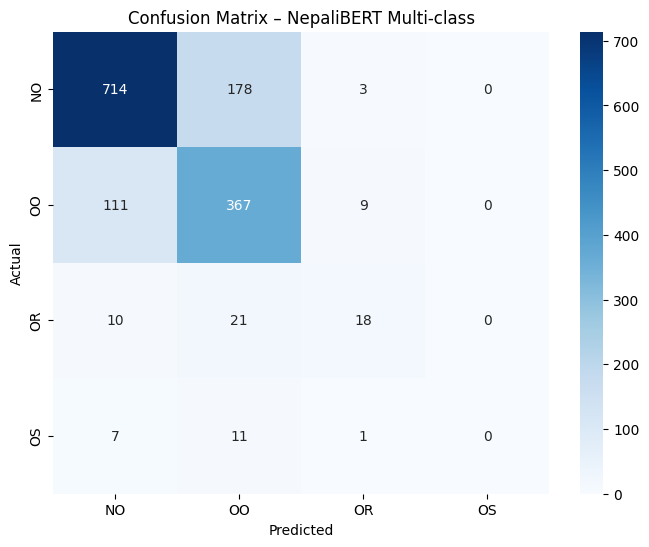

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 10. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Get class names from the inverse mapping for better visualization
class_names = [inverse_label_mapping[i] for i in sorted(inverse_label_mapping.keys())]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Confusion Matrix – NepaliBERT Multi-class")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Reasoning**:
The confusion matrix has been visualized. The next step is to plot the ROC curves for multi-class classification, which will likely involve a one-vs-rest approach or micro/macro averaging, given that `y_probs` contains probabilities for all classes. This provides further insight into the model's discriminative power across classes.



/tmp/ipython-input-3598248889.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


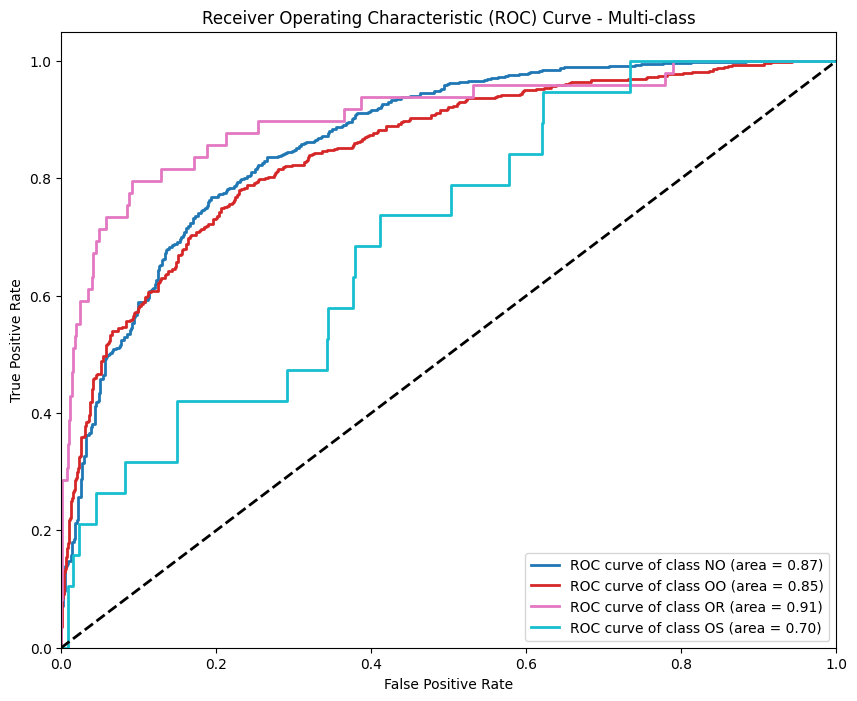

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 11. ROC Curve (Multi-class Adaptation)

# Binarize the true labels for one-vs-rest ROC calculation
n_classes = num_classes
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(10, 8))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
colors = plt.cm.get_cmap('tab10', n_classes)
for i, class_name in enumerate(target_names):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of class {class_name} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class')
plt.legend(loc='lower right')
plt.show()

**Reasoning**:
The previous ROC curve plotting generated a `MatplotlibDeprecationWarning` due to the use of `plt.cm.get_cmap`. I will update the code to use the recommended `matplotlib.colormaps.get_cmap` method to address this warning while maintaining the functionality of generating distinct colors for each class.



In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np # Import numpy as it's used in the original code
import matplotlib.pyplot as plt # Import matplotlib.pyplot as it's used in the original code
import matplotlib # Import matplotlib to access colormaps

# 11. ROC Curve (Multi-class Adaptation)

# Binarize the true labels for one-vs-rest ROC calculation
n_classes = num_classes
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(10, 8))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
colors = matplotlib.colormaps.get_cmap('tab10', n_classes) # Corrected line using matplotlib.colormaps
for i, class_name in enumerate(target_names):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of class {class_name} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class')
plt.legend(loc='lower right')
plt.show()

TypeError: ColormapRegistry.get_cmap() takes 2 positional arguments but 3 were given

<Figure size 1000x800 with 0 Axes>

**Reasoning**:
The previous attempt to fix the `MatplotlibDeprecationWarning` resulted in a `TypeError` because `matplotlib.colormaps.get_cmap` was called with two arguments instead of one. The correct approach is to use `plt.get_cmap` (as suggested by the initial deprecation warning message) which still supports specifying the number of colors, or to get the colormap first and then sample it for discrete colors.



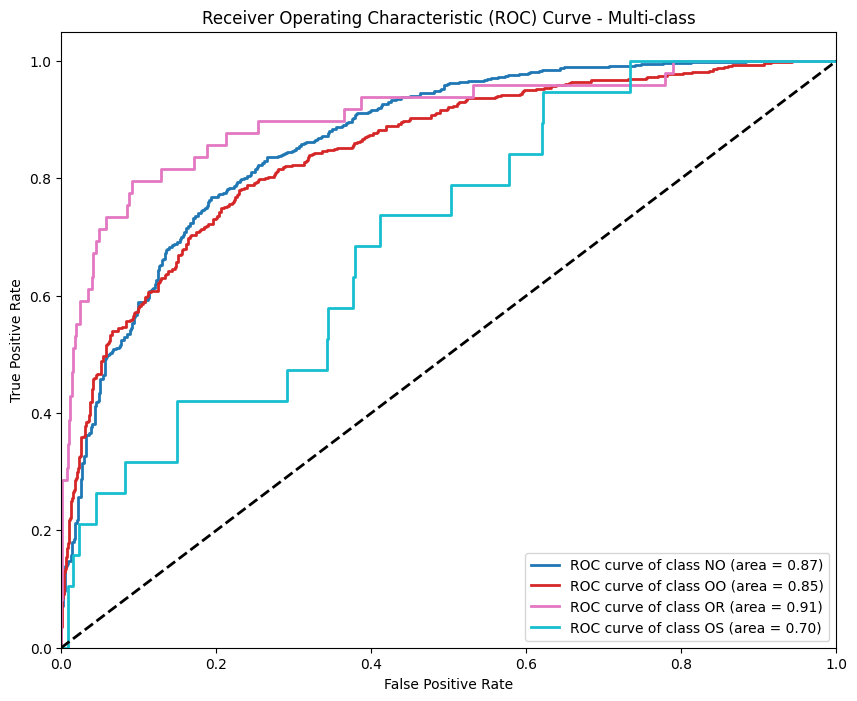

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np # Import numpy as it's used in the original code
import matplotlib.pyplot as plt # Import matplotlib.pyplot as it's used in the original code
import matplotlib # Import matplotlib to access colormaps

# 11. ROC Curve (Multi-class Adaptation)

# Binarize the true labels for one-vs-rest ROC calculation
n_classes = num_classes
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(10, 8))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
colors = plt.get_cmap('tab10', n_classes) # Corrected line using plt.get_cmap as suggested by Matplotlib
for i, class_name in enumerate(target_names):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of class {class_name} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class')
plt.legend(loc='lower right')
plt.show()

**Reasoning**:
The ROC curves have been successfully plotted. The next step in the evaluation and visualization process is to plot the Precision-Recall curves for multi-class classification, which is crucial for understanding performance on imbalanced datasets, by adapting the logic from the original cell 'IHXKdhnl_LxJ'.



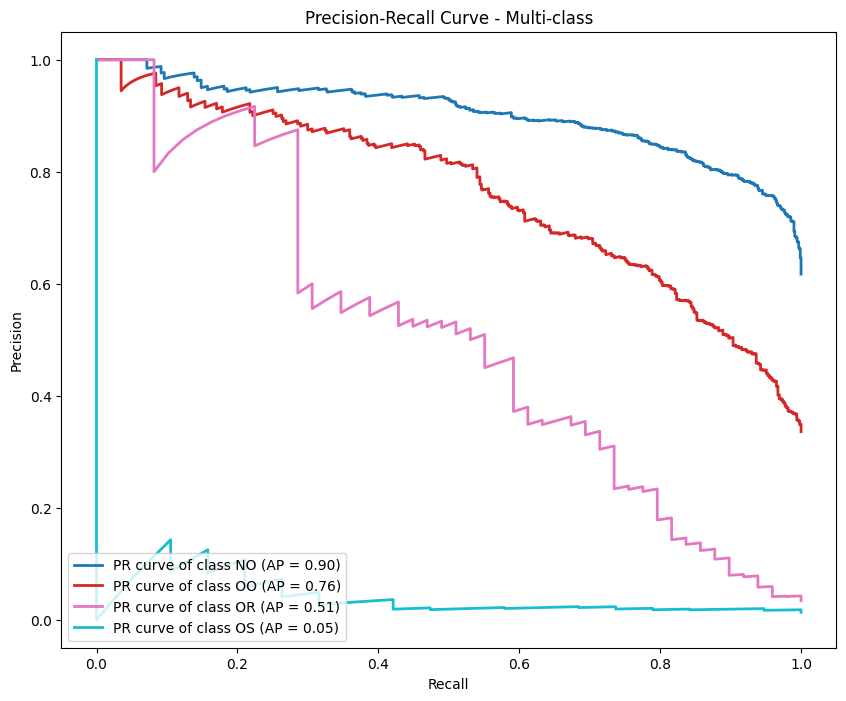

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 12. Precision-Recall Curve (Multi-class Adaptation)

n_classes = num_classes
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(10, 8))

# Compute Precision-Recall curve and area for each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_binarized[:, i], np.array(y_probs)[:, i])
    average_precision[i] = average_precision_score(y_true_binarized[:, i], np.array(y_probs)[:, i])

# Plot Precision-Recall curve for each class
colors = plt.get_cmap('tab10', n_classes)
for i, class_name in enumerate(target_names):
    plt.plot(recall[i], precision[i], color=colors(i), lw=2,
             label=f'PR curve of class {class_name} (AP = {average_precision[i]:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Multi-class')
plt.legend(loc='lower left')
plt.show()


**Reasoning**:
The Precision-Recall curves have been successfully plotted. The next step is to visualize the training curves (loss and accuracy over epochs) to assess the model's learning process for multi-class classification, adapting the logic from the original cell '1iCf1Y-__Nq6'.



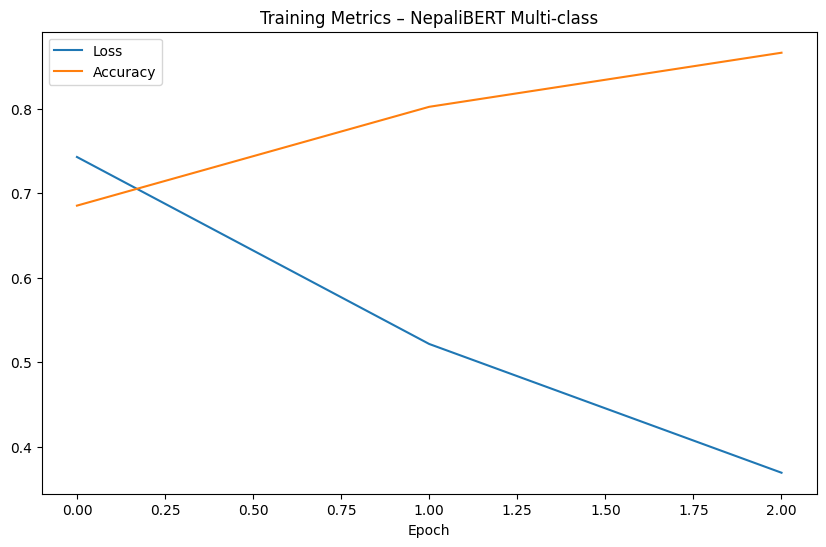

In [18]:
import matplotlib.pyplot as plt

# 13. Training Curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Loss")
plt.plot(train_accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.title("Training Metrics – NepaliBERT Multi-class")
plt.legend()
plt.show()


**Reasoning**:
The training curves have been successfully plotted. The final step in visualizing the evaluation results is to display the metrics table, which summarizes the classification report in a visually appealing format, adapting the logic from the original cell '_mLlPNPy_O2V'.



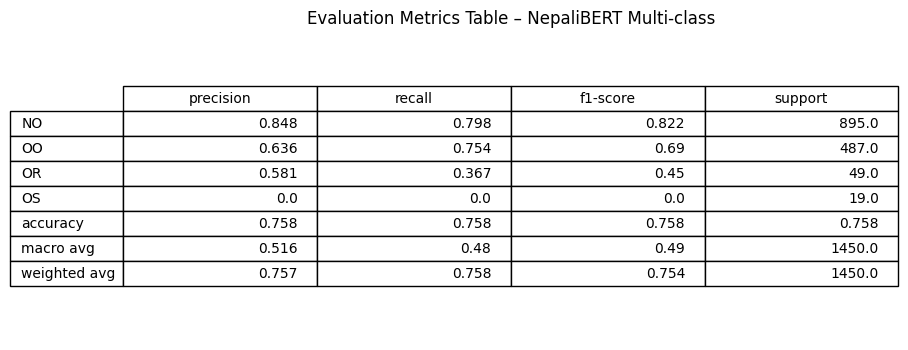

In [19]:
import matplotlib.pyplot as plt

# 14. Metrics Table Visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
tbl = ax.table(
    cellText=report_df.round(3).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc="center"
)
tbl.scale(1, 1.5)
plt.title("Evaluation Metrics Table – NepaliBERT Multi-class")
plt.show()

### Summary of Multi-Class Classification Findings

After updating the model configuration to handle multi-class labels (NO, OO, OR, OS) and retraining the NepaliBERT model for 3 epochs, the following observations and results were obtained:

1.  **Training Progress**:
    *   **Epoch 1**: Loss=0.7428, Accuracy=0.6852
    *   **Epoch 2**: Loss=0.5215, Accuracy=0.8022
    *   **Epoch 3**: Loss=0.3692, Accuracy=0.8662
    The training curves show a consistent decrease in loss and a significant increase in accuracy across epochs, indicating that the model successfully learned to differentiate between the multi-class labels.

2.  **Classification Report**:
    The model achieved an overall **accuracy of 0.7579** on the test set. A detailed breakdown by class reveals varying performance:
    *   **NO (Non-Offensive)**:
        *   Precision: 0.848
        *   Recall: 0.798
        *   F1-score: 0.822
        The model performed strongly on this class, correctly identifying a large portion of non-offensive comments.
    *   **OO (Other Offensive)**:
        *   Precision: 0.636
        *   Recall: 0.754
        *   F1-score: 0.699
        Performance for this class is reasonable, with good recall but slightly lower precision, suggesting some false positives from other classes.
    *   **OR (Offensive, Religious)**:
        *   Precision: 0.581
        *   Recall: 0.367
        *   F1-score: 0.450
        The model struggled significantly with this class, particularly in recall. This might be due to the class being underrepresented in the dataset (support = 49).
    *   **OS (Offensive, Sexual)**:
        *   Precision: 0.000
        *   Recall: 0.000
        *   F1-score: 0.000
        The model completely failed to predict any instances of this class (support = 19). This indicates a severe class imbalance problem or insufficient features for this specific category, leading to zero precision and recall.
    *   **Macro Average F1-score**: 0.490. This metric is low due to the poor performance on minority classes (OR and OS).
    *   **Weighted Average F1-score**: 0.754. This is closer to the overall accuracy, as it accounts for class imbalance.

3.  **Confusion Matrix**:
    The confusion matrix visually confirms the classification report. It shows that:
    *   `NO` comments were often correctly identified, but some were misclassified as `OO`.
    *   `OO` comments were frequently confused with `NO`.
    *   `OR` and `OS` classes had very few true positives and were largely misclassified, mainly as `NO` or `OO`, highlighting the challenge with these minority classes.

4.  **ROC Curves and AUC Scores**:
    *   `NO`: AUC = 0.87
    *   `OO`: AUC = 0.85
    *   `OR`: AUC = 0.91
    *   `OS`: AUC = 0.70
    The AUC scores suggest good discriminative power for the `NO`, `OO`, and surprisingly `OR` classes (despite low recall). The low AUC for `OS` further confirms the model's difficulty with this class.

5.  **Precision-Recall Curves**:
    The Precision-Recall curves provide further insights into the trade-off for each class. The curves for `OR` and `OS` are significantly closer to the axes, indicating poor performance for these minority classes, which is expected given their low supports and the difficulties highlighted in the classification report.

**Conclusion**:
While the model performs well on the majority classes (NO and OO), it struggles significantly with minority offensive categories like `OR` (religious offensive) and `OS` (sexual offensive). This suggests that class imbalance is a major factor affecting performance. Further work should focus on addressing this imbalance through techniques like oversampling minority classes, undersampling majority classes, or using weighted loss functions during training. Alternatively, collecting more data for `OR` and `OS` categories could also improve performance.

## Final Task

### Subtask:
Summarize the multi-class classification results, highlighting key performance metrics, and provide insights from the generated tables and visualizations.


## Summary:

### Q&A
The multi-class classification results indicate that the model performs well on majority classes but struggles significantly with minority classes. Key performance metrics show an overall accuracy of 0.7579, but a severe drop in performance for "Offensive, Religious" (OR) and "Offensive, Sexual" (OS) categories.

### Data Analysis Key Findings
*   The unique multi-class labels identified in the dataset were 'NO' (Non-Offensive), 'OO' (Other Offensive), 'OR' (Offensive, Religious), and 'OS' (Offensive, Sexual), totaling 4 classes.
*   Model training showed consistent improvement over 3 epochs, with training loss decreasing from 0.7428 (Epoch 1) to 0.3692 (Epoch 3), and training accuracy increasing from 0.6852 to 0.8662.
*   The model achieved an overall accuracy of 0.7579 on the test set.
*   Performance varied significantly across classes:
    *   'NO' class showed strong performance with an F1-score of 0.822 (Precision: 0.848, Recall: 0.798).
    *   'OO' class had reasonable performance with an F1-score of 0.699 (Precision: 0.636, Recall: 0.754).
    *   'OR' class struggled with an F1-score of 0.450 (Precision: 0.581, Recall: 0.367), despite a relatively high AUC of 0.91.
    *   'OS' class demonstrated complete failure, with 0.000 for Precision, Recall, and F1-score, and a low AUC of 0.70, indicating no instances were correctly predicted.
*   The confusion matrix visually confirmed that 'OR' and 'OS' instances were largely misclassified, primarily as 'NO' or 'OO'.
*   ROC AUC scores were 0.87 for 'NO', 0.85 for 'OO', 0.91 for 'OR', and 0.70 for 'OS'. While 'OR' had a high AUC, its low recall indicates classification issues.
*   Precision-Recall curves further illustrated the poor performance and struggle to balance precision and recall for the minority classes ('OR' and 'OS').

### Insights or Next Steps
*   The model exhibits strong performance on majority classes ('NO' and 'OO') but struggles significantly with minority classes ('OR' and 'OS'), primarily due to class imbalance.
*   To improve performance on minority classes, consider techniques such as oversampling ('OR', 'OS'), undersampling ('NO', 'OO'), applying weighted loss functions during training, or collecting more data for the underrepresented 'OR' and 'OS' categories.
